In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  
import plotly.graph_objects as go 


In [59]:
ks = pd.read_csv("C:/Users/Пользователь/Downloads/kickstarter_preparation (1).csv")

## **Проверка гипотез для данных с kikstarter**

1) Количество слов в названии влияет на сумму сборов 

2) Присутсвует зависимость суммы сборов от создателя проекта — если у человека много проектов, то выше шанс собрать деньги

3) Страна проекта влияет на сборы 

4) Проекты с видео имеют большие сборы

5) Проекты  попавшие  в раздел «В центре внимания»  имеют большие сборы                         

6) Если проект отобрали редакторы платформы, то у него выше сборы


**Гипотеза 1**

In [60]:
#cоздаем дополнительный столбец с суммой слов
ks['sum_words']  = ks['blurb'].fillna('').str.split(' ')
for i in range(len(ks)):
    ks.loc[i, 'sum_words'] = len(ks.loc[i, 'sum_words'])

In [61]:
ks['usd_pledged_per_day'] = round(ks['usd_pledged_per_day'],2)

In [62]:
corr = ks[['usd_pledged_per_day', 'sum_words']].corr(method='spearman')

In [63]:
corr

,usd_pledged_per_day,sum_words
usd_pledged_per_day,1.000000,0.017734
sum_words,0.017734,1.000000


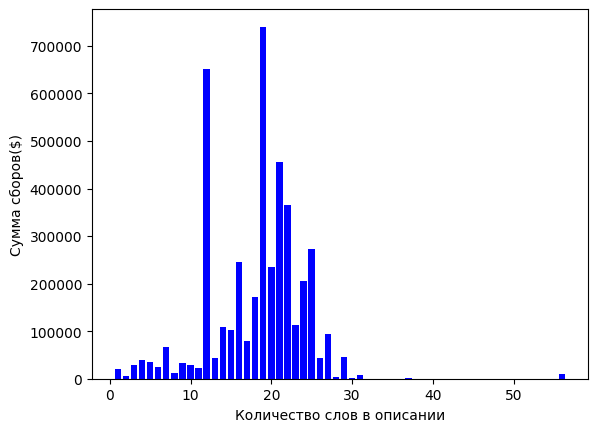

In [64]:
plt.bar(ks['sum_words'], ks['usd_pledged_per_day'], color='blue')
plt.xlabel('Количество слов в описании')
plt.ylabel('Сумма сборов($)')
plt.show()

In [65]:
corr = ks[['percent_funded', 'sum_words']].corr(method='spearman')
corr

,percent_funded,sum_words
percent_funded,1.000000,-0.018274
sum_words,-0.018274,1.000000


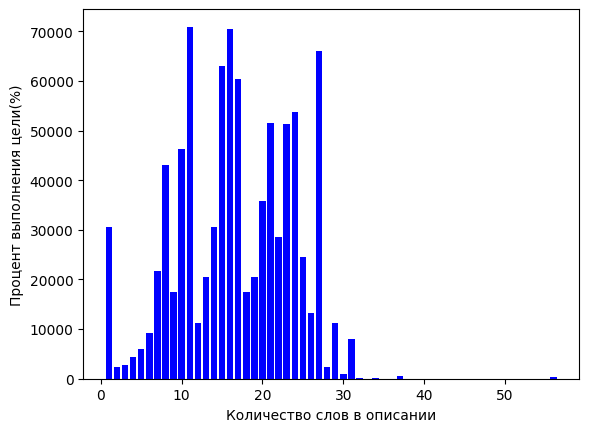

In [66]:
plt.bar(ks['sum_words'], ks['percent_funded'], color='blue')
plt.xlabel('Количество слов в описании')
plt.ylabel('Процент выполнения цели(%)')
plt.show()

**Вывод по 1 гипотезе:**
Мы видим что у признаков отстутсвует зависимость между количеством слов в описании и суммой сборов, а также процентом выполнения цели

**Гипотеза 2**

In [67]:
svod_creator = ks.groupby('creator_id').agg({'usd_pledged_per_day':'median','percent_funded':'median','creator_id': 'count'}).rename(columns ={'creator_id': 'projects_count'})

<Axes: >

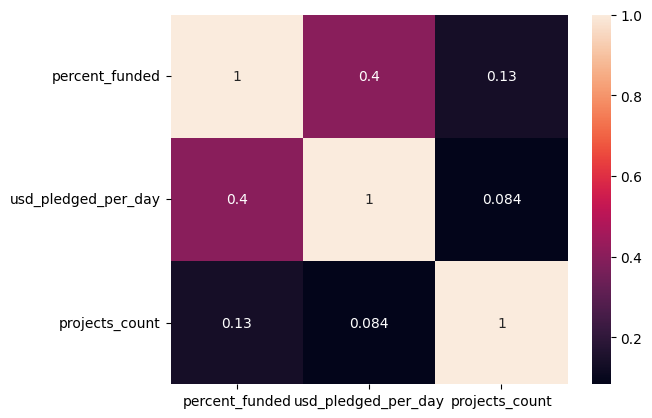

In [68]:
corr = svod_creator[['percent_funded','usd_pledged_per_day', 'projects_count']].corr(method='spearman')
sns.heatmap(corr, annot=True)

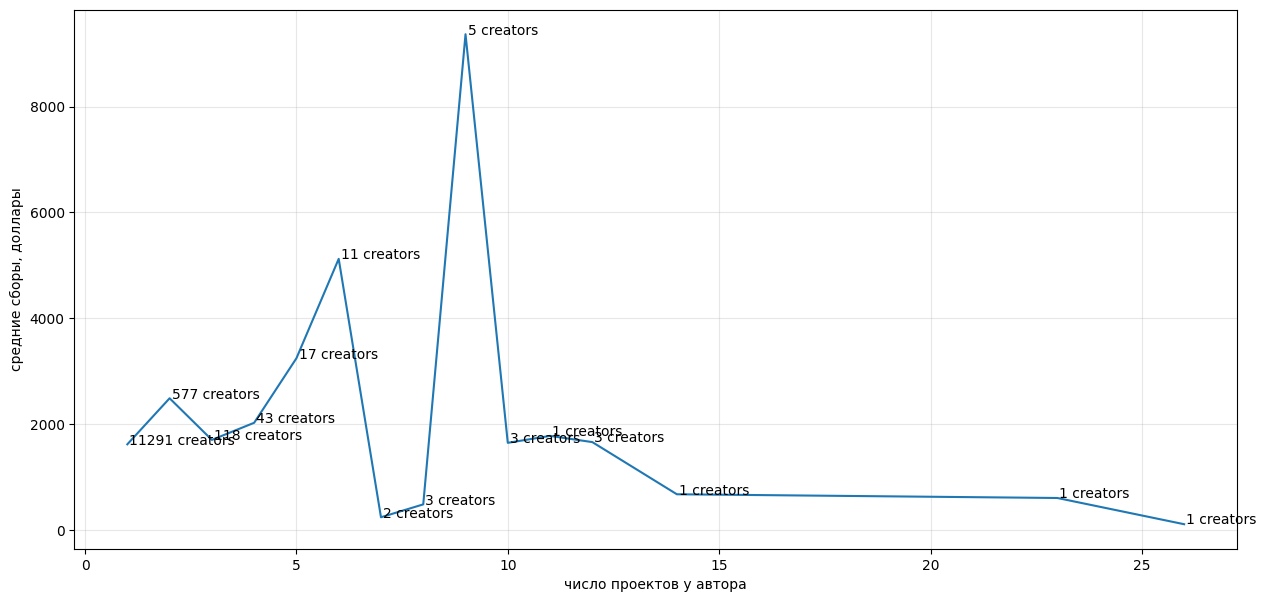

In [69]:
plt.figure(figsize=(15, 7))
grouped_by_author = ks.groupby(by="creator_id").agg(
    num_prog = pd.NamedAgg(column="id", aggfunc="count"),
    mean_fundings = pd.NamedAgg(column="usd_pledged_per_day", aggfunc="mean")
)
grouped_by_author = grouped_by_author.reset_index()
creators_dist = grouped_by_author.num_prog.value_counts()
grouped_by_num = grouped_by_author.groupby(by="num_prog").agg(
    mean_fundings=pd.NamedAgg(column="mean_fundings", aggfunc="mean")
)
plt.plot(grouped_by_num.index, grouped_by_num['mean_fundings'])
plt.xlabel('число проектов у автора')
plt.ylabel('средние сборы, доллары')

for x_coord, y_coord in zip(grouped_by_num.index, grouped_by_num['mean_fundings']):
    amount_of_creators = creators_dist[x_coord]
    plt.text(x_coord + 0.05, y_coord, f'{amount_of_creators} creators')


plt.grid(True, alpha=0.3)

plt.show()


**Выводы по гипотезе 2:**

Мы видим что количество проектов автора совсем не коррелирует с суммой сборов

С процентов выполнения цели корреляция есть, но совсем небольшая - всего 0.14

Также стоит отметить, что % достижения цели и сборы имеют не совсем высокую корреляцию. Происходит это из-за того, что проект изначально мог иметь очень низкую цель, и даже собрав, скажем, 10 долларов, проект может иметь percent_funded 1000%, а проект, у которого изначально была высокая цель, может иметь percent_funded лишь 1–2%

**Гипотеза 3**

In [70]:
svod_table = pd.pivot_table(ks, values=['usd_pledged_per_day', 'percent_funded'], index = 'country', aggfunc={'usd_pledged_per_day' : 'median', 'percent_funded' :'median'})
svod_table

,percent_funded,usd_pledged_per_day
country,,
AT,112.469128,200.820
AU,131.332833,283.960
BE,115.920742,127.615
CA,140.405128,255.755
CH,140.437037,628.540
DE,122.800000,338.910
DK,155.000000,647.070
ES,143.916667,207.910
FR,121.026667,264.150


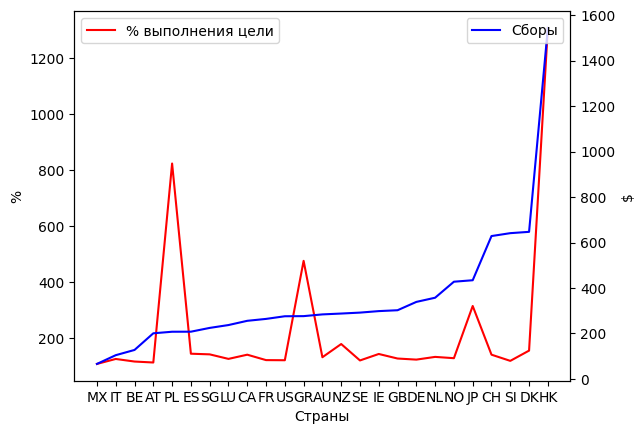

In [71]:
f = svod_table.sort_values('usd_pledged_per_day')
ax1 = plt.subplot()
ax1.plot(f.index, f['percent_funded'], color = 'red', label = '% выполнения цели')
ax1.set_ylabel('%')
ax1.set_xlabel('Страны')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot( f.index, f['usd_pledged_per_day'], color = 'blue', label = 'Сборы')
ax2.set_ylabel('$')
ax2.legend(loc='upper right')

plt.show()


HK - Гонконг

**Гипотеза 4**

In [72]:
ks['flag_video'] = ks['video_id'].fillna('0').apply(lambda x: x if x == '0' else '1')

In [86]:
ks['usd_goal'] = ks['goal']*ks['static_usd_rate']

In [90]:
svod_table6 = pd.pivot_table(ks, values=['usd_pledged_per_day', 'percent_funded', 'usd_goal'], index = 'flag_video', aggfunc={'usd_pledged_per_day' : 'median', 'percent_funded' :'median', 'usd_goal': 'median'})
svod_table6

,percent_funded,usd_goal,usd_pledged_per_day
flag_video,,,
0,136.195833,1968.511687,126.86
1,122.128250,6500.000000,322.49


In [91]:
svod_table6 = pd.pivot_table(ks, values=['usd_pledged_per_day', 'percent_funded', 'usd_goal'], index = 'flag_video', aggfunc={'usd_pledged_per_day' : 'mean', 'percent_funded' :'mean', 'usd_goal': 'mean'})
svod_table6

,percent_funded,usd_goal,usd_pledged_per_day
flag_video,,,
0,644.900496,6912.654671,680.996334
1,482.008176,16509.643566,1928.337259


**Выводы:**

Зависимость действительно присутствует. Мы видим, что при наличии видео проекты собирают бОльшие суммы, однако бОльший процент выполнения цели у проектов без видео.

Происходит это потому, что проекты без видео изначально имеют меньшие цели, и из-за этого процент достижения у них выше, несмотря на меньшие сборы.

**Гипотеза 5**

In [75]:
np.percentile(ks[ks['spotlight'] == False]['percent_funded'], 95)

np.float64(1777.173999999997)

In [76]:
np.percentile(ks[ks['spotlight'] == True]['percent_funded'], 95)

np.float64(1702.4719999999945)

In [77]:
np.percentile(ks[ks['spotlight'] == False]['percent_funded'], 100)

np.float64(34182.4)

In [78]:
np.percentile(ks[ks['spotlight'] == True]['percent_funded'], 100)

np.float64(70946.0)

In [79]:
ks[(ks['percent_funded'] == 34182.4) | (ks['percent_funded'] == 70946.0)]

,index,id,name,blurb,goal,pledged,state,country,country_displayable_name,currency,...,category_name,category_slug,category_parent_id,category_parent_name,video_id,end,days,usd_pledged_per_day,sum_words,flag_video
500,1,632098548,How to THINK when you DRAW BOOK 9 + REPRINTS +...,The 9th 200 PAGE BOOK of Lorenzo Etherington's...,1000.0,341824.0,live,GB,the United Kingdom,GBP,...,Comics,comics,0.0,0,1413171.0,2026-04-02 00:00:00,38,12125.75,23,1
788,7992,84728891,Oceanus Brass Stapler,"Locks paper, staples not required | Nautically...",250.0,177365.0,successful,US,the United States,USD,...,Product Design,design/product design,7.0,Design,1386855.0,2025-11-19 01:00:00,56,3167.23,11,1


In [80]:
svod_table2 = pd.pivot_table(ks, values=['usd_pledged_per_day', 'percent_funded'], index = 'spotlight', aggfunc={'usd_pledged_per_day' : 'median', 'percent_funded' :'median'})
svod_table2

,percent_funded,usd_pledged_per_day
spotlight,,
False,69.196154,110.88
True,125.762712,314.11


In [81]:
svod_table2 = pd.pivot_table(ks, values=['usd_pledged_per_day', 'percent_funded'], index = 'spotlight', aggfunc={'usd_pledged_per_day' : 'mean', 'percent_funded' :'mean'})
svod_table2

,percent_funded,usd_pledged_per_day
spotlight,,
False,429.319107,3409.602804
True,517.842327,1479.606520


**Выводы: по гипотезе 5**

В целом можно сказать, что успешность проекта действительно связана с попаданием в Spotlight, но даже если ваш проект туда не попадет, он всё равно может выстрелить и собрать очень большую сумму

**Гипотеза 6**

In [82]:
svod_table3 = pd.pivot_table(ks, values=['usd_pledged_per_day', 'percent_funded'], index = 'staff_pick', aggfunc={'usd_pledged_per_day' : 'median', 'percent_funded' :'median'})
svod_table3

,percent_funded,usd_pledged_per_day
staff_pick,,
False,112.600000,123.190
True,127.947917,387.015


In [83]:
svod_table3 = pd.pivot_table(ks, values=['usd_pledged_per_day', 'percent_funded'], index = 'staff_pick', aggfunc={'usd_pledged_per_day' : 'mean', 'percent_funded' :'mean'})
svod_table3

,percent_funded,usd_pledged_per_day
staff_pick,,
False,463.876636,650.928876
True,523.590369,2224.605671


**Выводы по гипотезе 6:**
Мы видим, что процент выполнения цели и сборы действительно зависят от того, отобрала ли платформа проект или нет


In [84]:
ks.to_csv('ks_final.csv' , index=False)